<a href="https://colab.research.google.com/github/ishikabeniwal/CSET343/blob/main/Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA

In [ ]:
!file diabetes.csv

diabetes.csv: compress'd data 16 bits


In [ ]:
df = pd.read_csv("diabetes.csv", encoding="latin1")

In [ ]:
# Inspect dataset
print("First five rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

First five rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset shape:
(768, 9)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies         

In [ ]:
# Replace medically implausible zero values with NaN
zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df[zero_columns] = df[zero_columns].replace(0, np.nan)


In [ ]:
# Fill missing values with median
for column in zero_columns:
    df[column] = df[column].fillna(df[column].median())

In [ ]:
# Remove duplicate rows
df = df.drop_duplicates()


Outcome distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


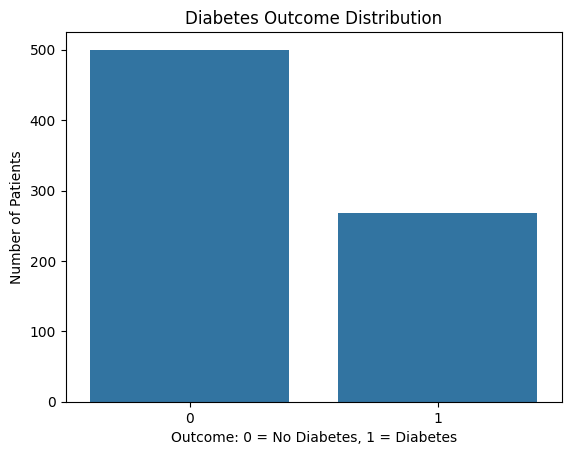

In [ ]:
# EDA: Outcome distribution
print("\nOutcome distribution:")
print(df["Outcome"].value_counts())

sns.countplot(x="Outcome", data=df)
plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome: 0 = No Diabetes, 1 = Diabetes")
plt.ylabel("Number of Patients")
plt.show()

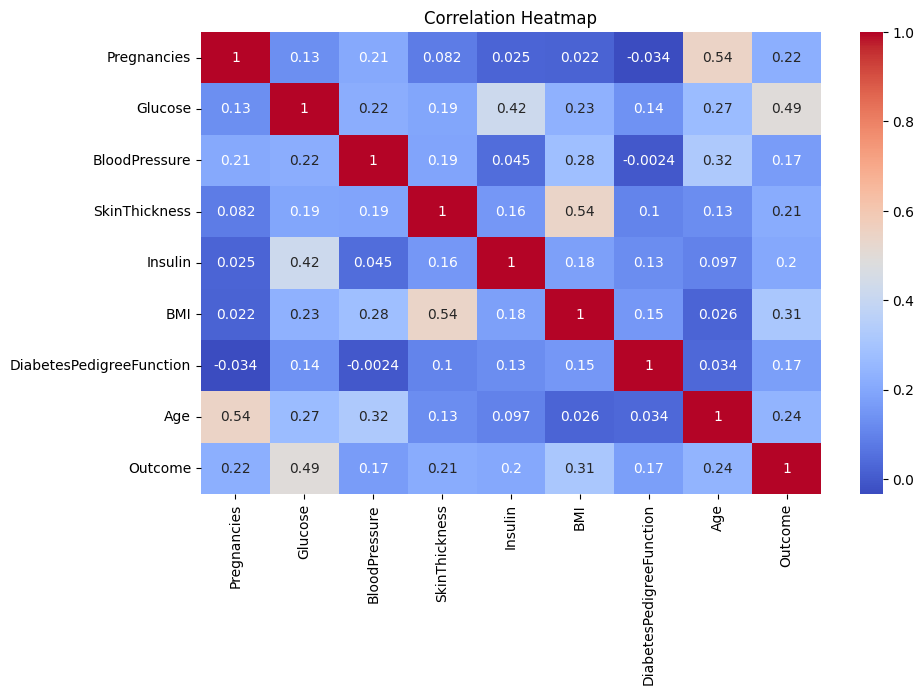

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# ------------------------------------------------------------
# HYPOTHESIS TEST: INDEPENDENT T-TEST
# ------------------------------------------------------------

diabetic = df[df["Outcome"] == 1]["Glucose"]
non_diabetic = df[df["Outcome"] == 0]["Glucose"]

t_stat, p_value = stats.ttest_ind(
    diabetic,
    non_diabetic,
    equal_var=False
)

print("\nHypothesis Test - Glucose")
print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")



Hypothesis Test - Glucose
T-statistic: 14.852653441079662
P-value: 3.5421485614431447e-41
Reject the null hypothesis.


In [ ]:
# ------------------------------------------------------------
# CHI-SQUARE TEST
# Age group and diabetes outcome
# ------------------------------------------------------------

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[20, 30, 40, 50, 100],
    labels=["21-30", "31-40", "41-50", "51+"]
)

contingency_table = pd.crosstab(
    df["AgeGroup"],
    df["Outcome"]
)

chi2, p_value, dof, expected = stats.chi2_contingency(
    contingency_table
)

print("\nChi-square Test")
print(contingency_table)
print("Chi-square statistic:", chi2)
print("P-value:", p_value)

if p_value < 0.05:
    print("Significant association.")
else:
    print("No significant association.")



Chi-square Test
Outcome     0   1
AgeGroup         
21-30     327  90
31-40      81  76
41-50      49  64
51+        43  38
Chi-square statistic: 73.80892085951109
P-value: 6.521685313585261e-16
Significant association.


In [ ]:
# ------------------------------------------------------------
# ANOVA TEST
# BMI across age groups
# ------------------------------------------------------------

groups = [
    group["BMI"].dropna().values
    for _, group in df.groupby("AgeGroup", observed=False)
]

f_stat, p_value = stats.f_oneway(*groups)

print("\nANOVA Test")
print("F-statistic:", f_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("At least one group mean is significantly different.")
else:
    print("No significant difference between group means.")


ANOVA Test
F-statistic: 5.389012455489131
P-value: 0.0011292814040803393
At least one group mean is significantly different.


In [ ]:
# ------------------------------------------------------------
# FEATURE ENGINEERING
# ------------------------------------------------------------

df["BMI_Age"] = df["BMI"] * df["Age"]

print("\nNew feature created: BMI_Age")
print(df[["BMI", "Age", "BMI_Age"]].head())



New feature created: BMI_Age
    BMI  Age  BMI_Age
0  33.6   50   1680.0
1  26.6   31    824.6
2  23.3   32    745.6
3  28.1   21    590.1
4  43.1   33   1422.3


In [ ]:
# ------------------------------------------------------------
# FEATURE SELECTION
# ------------------------------------------------------------

X = df.drop(columns=["Outcome", "AgeGroup"])
y = df["Outcome"]

selector = SelectKBest(
    score_func=f_classif,
    k=5
)

X_selected = selector.fit_transform(X, y)

print("\nSelected feature shape:", X_selected.shape)


Selected feature shape: (768, 5)


In [ ]:
# ------------------------------------------------------------
# FEATURE EXTRACTION USING PCA
# ------------------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("PCA shape:", X_pca.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)


PCA shape: (768, 2)
Explained variance ratio: [0.33705533 0.17277264]


In [ ]:
# ============================================================
# PART B: TEXTUAL DATA
# MTSAMPLES MEDICAL TRANSCRIPTIONS
# ============================================================

import re
from sklearn.feature_extraction.text import TfidfVectorizer

# Load textual dataset
text_df = pd.read_csv("mtsamples.csv")

print("\nText dataset columns:")
print(text_df.columns)

# Remove rows with missing transcription
text_df = text_df.dropna(subset=["transcription"])

# Text cleaning function
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

# Apply cleaning
text_df["cleaned_text"] = text_df["transcription"].apply(
    clean_text
)

# Tokenization
text_df["tokens"] = text_df["cleaned_text"].apply(
    lambda x: x.split()
)

# Convert text into numerical features
vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words="english"
)

X_text = vectorizer.fit_transform(
    text_df["cleaned_text"]
)

print("\nTF-IDF matrix shape:", X_text.shape)
print("Example tokens:", text_df["tokens"].iloc[0][:10])


Text dataset columns:
Index(['Unnamed: 0', 'description', 'medical_specialty', 'sample_name',
       'transcription', 'keywords'],
      dtype='object')

TF-IDF matrix shape: (4966, 1000)
Example tokens: ['subjective', 'this', 'yearold', 'white', 'female', 'presents', 'with', 'complaint', 'of', 'allergies']


In [ ]:
# ============================================================
# PART C: IMAGE DATA
# CHEST X-RAY
# ============================================================

from PIL import Image

# Change this path to your X-ray image path
image_path = "chest_xray/sample.jpeg"

try:
    # Load image
    image = Image.open(image_path)

    print("\nOriginal image size:", image.size)
    print("Original image mode:", image.mode)

    # Resize image
    image = image.resize((224, 224))

    # Convert image to NumPy array
    image_array = np.array(image)

    # Normalize pixel values
    image_array = image_array / 255.0

    print("Processed image shape:", image_array.shape)

    # Display image
    plt.imshow(image, cmap="gray")
    plt.title("Preprocessed Chest X-Ray")
    plt.axis("off")
    plt.show()

    # Image augmentation
    augmented_image = image.rotate(10)

    plt.imshow(augmented_image, cmap="gray")
    plt.title("Augmented Chest X-Ray")
    plt.axis("off")
    plt.show()

except FileNotFoundError:
    print("\nImage file not found.")
    print("Update image_path with your X-ray file path.")



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 1.9 MB/s eta 0:00:00

ECG signal length: 650000
Sampling frequency: 360


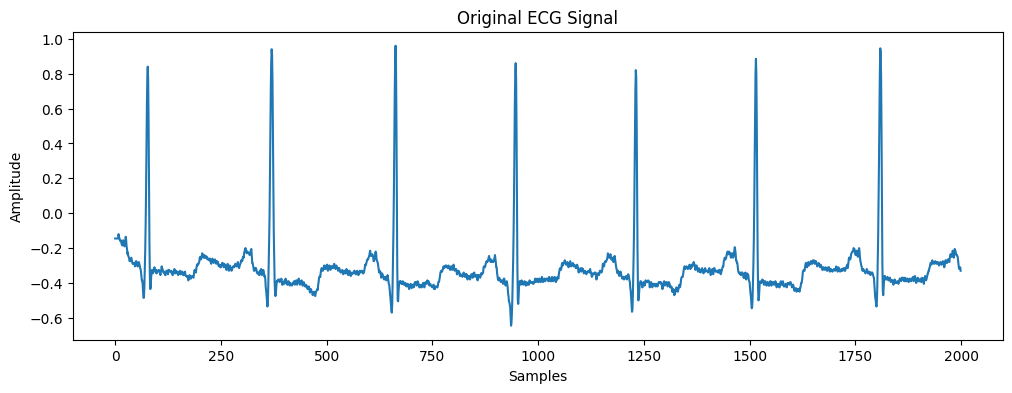

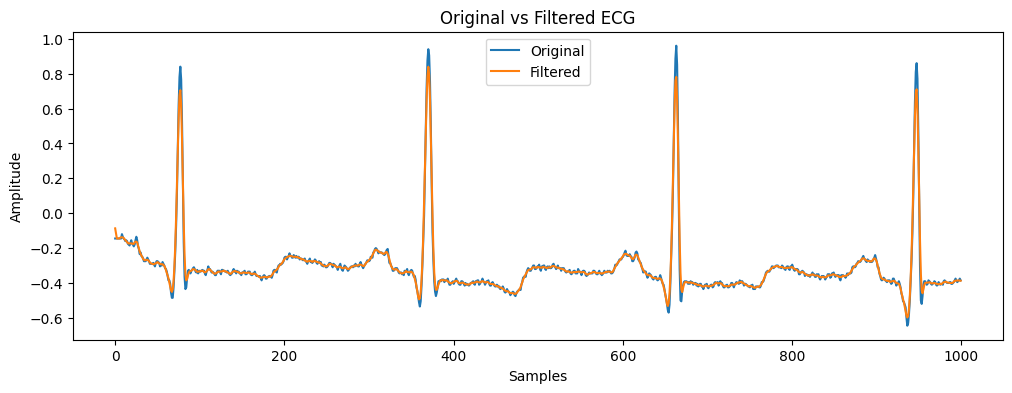

Signal windows shape: (3611, 180)


In [31]:
# ============================================================
# PART D: SIGNAL DATA
# MIT-BIH ARRHYTHMIA DATABASE (ECG)
# ============================================================

# Run this separately in Google Colab if required:
# !pip install wfdb

!pip install wfdb
import wfdb

try:
    # Read ECG record 100
    record = wfdb.rdrecord(
        "100",
        pn_dir="mitdb"
    )

    # Select first ECG channel
    signal = record.p_signal[:, 0]

    print("\nECG signal length:", len(signal))
    print("Sampling frequency:", record.fs)

    # Plot original ECG signal
    plt.figure(figsize=(12, 4))
    plt.plot(signal[:2000])
    plt.title("Original ECG Signal")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.show()

    # Noise removal using moving average
    window_size = 5

    kernel = np.ones(window_size) / window_size

    filtered_signal = np.convolve(
        signal,
        kernel,
        mode="same"
    )

    # Compare original and filtered signal
    plt.figure(figsize=(12, 4))
    plt.plot(signal[:1000], label="Original")
    plt.plot(filtered_signal[:1000], label="Filtered")

    plt.title("Original vs Filtered ECG")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.show()

    # Create signal windows
    window_length = 180
    windows = []

    for i in range(
        0,
        len(filtered_signal) - window_length,
        window_length
    ):
        window = filtered_signal[
            i:i + window_length
        ]

        windows.append(window)

    windows = np.array(windows)

    print("Signal windows shape:", windows.shape)

except Exception as error:
    print("\nECG dataset could not be loaded.")
    print("Install wfdb and check internet connection.")
    print("Error:", error)